# TAE-IA · Module 6 · L05 — ControlNet: Structure-Guided Generation

| | |
|---|---|
| **Module** | 6 — Practical AI Applications: Images and Audio |
| **Lesson** | L05 |
| **Track** | A — Vision |
| **Estimated duration** | 2 hours |
| **GPU required** | T4 (Colab) |
| **Prerequisites** | L01–L04 completed; L04 cleanup cell run |

## Learning objectives
By the end of this notebook you will be able to:
- [ ] Explain how ControlNet injects conditioning signals into the UNet without modifying its frozen weights
- [ ] Extract Canny edges and depth maps as conditioning inputs
- [ ] Use `StableDiffusionControlNetPipeline` with Canny and depth conditioners
- [ ] Tune `controlnet_conditioning_scale` and explain its effect

## Before you start
- L04 cleanup cell must have been run — frees Drive space for this lab's models
- T4 GPU runtime selected (`Runtime > Change runtime type > T4 GPU`)

---

## Cell 0 — Setup (always run this first)

> Mounts Drive, checks GPU, fixes seed.

In [1]:
# ================================================================
# TAE-IA M6 · Standard Setup -- DO NOT MODIFY THIS CELL
# ================================================================
import os, sys, random, shutil
import numpy as np

from google.colab import drive
drive.mount('/content/drive')

MODEL_CACHE = '/content/drive/MyDrive/Colab Notebooks/Module 6/Dr. Francisco J. Rodriguez/models'
os.makedirs(MODEL_CACHE, exist_ok=True)
print(f'Model cache: {MODEL_CACHE}')

# Clear any cache left by earlier course versions.
for _leftover in ('hub', 'xet'):
    _p = os.path.join(MODEL_CACHE, _leftover)
    if os.path.exists(_p):
        shutil.rmtree(_p)

import torch
if not torch.cuda.is_available():
    print('\nNo GPU detected. Go to: Runtime > Change runtime type > T4 GPU')
    raise SystemExit('GPU required.')

gpu_name = torch.cuda.get_device_name(0)
vram_gb  = torch.cuda.get_device_properties(0).total_memory / 1e9
print(f'GPU: {gpu_name}  |  VRAM: {vram_gb:.1f} GB')

SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
print(f'Fixed seed: {SEED}')
print(f'Python {sys.version.split()[0]}  |  PyTorch {torch.__version__}')

Mounted at /content/drive
Model cache: /content/drive/MyDrive/Colab Notebooks/Module 6/Dr. Francisco J. Rodriguez/models
GPU: Tesla T4  |  VRAM: 15.6 GB
Fixed seed: 42
Python 3.13.15  |  PyTorch 2.11.0+cu128


In [2]:
# ================================================================
# Install dependencies for L05
# controlnet-aux provides preprocessing detectors (Canny, MiDaS, etc.)
# ================================================================
!pip install diffusers transformers accelerate controlnet-aux opencv-python-headless -q

import diffusers, controlnet_aux, cv2
print(f'diffusers {diffusers.__version__}  |  controlnet-aux {controlnet_aux.__version__}  |  OpenCV {cv2.__version__}')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 290.4/290.4 kB 12.3 MB/s eta 0:00:00


/usr/local/lib/python3.13/dist-packages/controlnet_aux/mediapipe_face/mediapipe_face_common.py:7: UserWarning: The module 'mediapipe' is not installed. The package will have limited functionality. Please install it using the command: pip install 'mediapipe'
  warnings.warn(


diffusers 0.40.0  |  controlnet-aux 0.0.10  |  OpenCV 5.0.0


/usr/local/lib/python3.13/dist-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
/usr/local/lib/python3.13/dist-packages/timm/models/registry.py:4: FutureWarning: Importing from timm.models.registry is deprecated, please import via timm.models
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.models", FutureWarning)
/usr/local/lib/python3.13/dist-packages/controlnet_aux/segment_anything/modeling/tiny_vit_sam.py:654: UserWarning: Overwriting tiny_vit_5m_224 in registry with controlnet_aux.segment_anything.modeling.tiny_vit_sam.tiny_vit_5m_224. This is because the name being registered conflicts with an existing name. Please check if this is not expected.
  return register_model(fn_wrapper)
/usr/local/lib/python3.13/dist-packages/controlnet_aux/segment_anything/mode

---
## Part 1 — Context and Key Concepts

> Read this before running any code.

### The problem text prompts cannot solve

Text prompts excel at controlling *what* is in the image and *how it looks* (style, color, mood). They are poor at controlling *where* things are, *how* the camera is positioned, or *what pose* a subject holds. Running the same composition-specific prompt ten times produces ten different layouts.

img2img partially solves this by starting from an existing image, but it requires a near-finished source — a rough sketch or wireframe gives poor results because img2img encodes the *pixels*, not the *structure*.

### ControlNet architecture

ControlNet (Zhang et al., 2023) adds a **trainable copy of the UNet encoder** alongside the frozen SD 1.5 model:

```
Conditioning image (Canny / depth)
    │
    ▼
ControlNet Encoder  ← trainable, initialized from UNet encoder weights
    │  outputs feature maps at each resolution scale
    ▼  added to UNet skip connections and mid block
UNet (frozen SD 1.5)
    │
    ▼
VAE Decoder → output image
```

Because the SD 1.5 weights are frozen, **all of its generation quality is preserved**. ControlNet only adds structural guidance on top.

### `controlnet_conditioning_scale`

This parameter (default `1.0`) controls how strongly the ControlNet signal influences the output:
- `0.5`: soft guidance — model has more creative freedom, structure loosely followed
- `1.0`: balanced — good default for most use cases
- `1.5+`: strict guidance — model rigidly follows the control signal, may reduce image quality

### Canny vs. Depth conditioning

- **Canny edges:** captures object outlines and internal structure. Best when the source has clear, meaningful edges (architecture, mechanical objects, illustrations). Over-sensitive to noise.
- **Depth map:** captures near/far relationships. More robust to texture and noise than Canny. Best for controlling perspective and 3D layout without locking in specific shapes.

Each conditioner requires its own ControlNet checkpoint — they are not interchangeable.

---

## Part 2 — Lab

### Section 2.0 — Load pipeline

Loads SD 1.5 once. Every ControlNet pipeline built later in this lab reuses these same loaded
components instead of reloading the base model from scratch — the original version of this
notebook reloaded SD 1.5 from scratch four separate times.

In [3]:
# Section 2.0 — Load pipeline
from diffusers import StableDiffusionPipeline
from huggingface_hub import snapshot_download
import torch, gc, os, cv2
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

def gen(seed=SEED):
    return torch.Generator("cuda").manual_seed(seed)

OUTPUT_DIR = "l05_outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Fetch only the fp16 weights + configs (~2.5 GB) -- shared with L01-L04 if already cached.
SD15_DIR = os.path.join(MODEL_CACHE, 'sd15-local')
snapshot_download(
    "runwayml/stable-diffusion-v1-5",
    local_dir=SD15_DIR,
    allow_patterns=["*.json", "*.txt", "*.fp16.safetensors"],
)

# Loaded once, kept alive for the whole notebook -- every ControlNet pipeline below reuses
# these components instead of reloading SD 1.5 from scratch.
pipe_txt = StableDiffusionPipeline.from_pretrained(
    SD15_DIR,
    torch_dtype=torch.float16,
    variant="fp16",
).to("cuda")
print("txt2img pipeline loaded (stays loaded for the rest of this notebook).")

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 15 files:   0%|          | 0/15 [00:00<?, ?it/s]

/usr/local/lib/python3.13/dist-packages/diffusers/utils/deprecation_utils.py:23: FutureWarning: `torch_dtype` is deprecated and will be removed in version 1.0.0. Please use `dtype` instead.
  deprecate("torch_dtype", "1.0.0", _TORCH_DTYPE_DEPRECATION_MESSAGE)


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

txt2img pipeline loaded (stays loaded for the rest of this notebook).


### Section 2.1 — Generate source image and extract Canny edges

  0%|          | 0/25 [00:00<?, ?it/s]

Source generated.
Canny edges extracted.


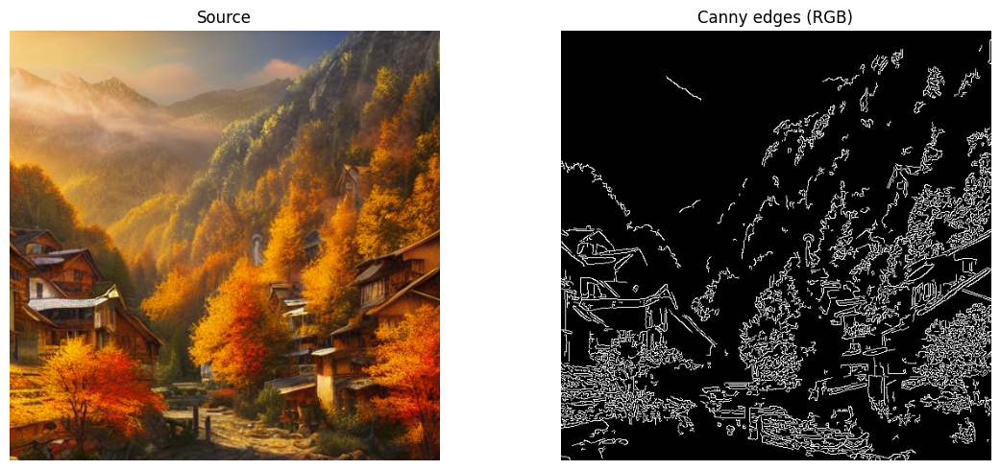

In [4]:
# Section 2.1 — Source image and Canny preprocessing
SOURCE_PROMPT = "a mountain village in autumn, warm golden light, photorealistic, high detail"
source = pipe_txt(
    SOURCE_PROMPT,
    num_inference_steps=25, guidance_scale=7.5, generator=gen()
).images[0]
source = source.resize((512, 512))
source.save(os.path.join(OUTPUT_DIR, "source.png"))
print("Source generated.")

# Extract Canny edges
gray         = np.array(source.convert("L"))
edges        = cv2.Canny(gray, threshold1=100, threshold2=200)
canny_image  = Image.fromarray(edges).convert("RGB")   # ControlNet expects RGB
canny_image.save(os.path.join(OUTPUT_DIR, "canny.png"))
print("Canny edges extracted.")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(source); axes[0].set_title("Source"); axes[0].axis('off')
axes[1].imshow(canny_image); axes[1].set_title("Canny edges (RGB)"); axes[1].axis('off')
plt.tight_layout(); plt.show()

**What do you observe?**  
- Which parts of the image produced the most edges? Which areas are sparse?
- Are there any edges that look like noise rather than real structure?

**Observation (Section 2.1 — Canny edge extraction):**

- **Densest edges:** the building facades and rooflines in the lower half of the image produced the strongest, most continuous edge lines. The angular roof geometry and wall corners create long, clean contour segments that Canny captures reliably.
- **Sparse areas:** the sky and misty upper mountain area produced almost no edges — there is very little contrast gradient in those zones, so Canny finds nothing to detect.
- **Noise-like edges:** the dense autumn foliage produced a large number of short, fragmented edge segments that represent individual leaf boundaries rather than meaningful structure. These "texture edges" may cause the model to over-constrain the tree mass area when used as a conditioning signal.
- **Practical implication:** Canny works best on images with strong, meaningful contours (architecture, mechanical objects). For organic, texture-heavy subjects (forests, fur, water), many detected edges are noise rather than compositional structure.

### Section 2.2 — Canny ControlNet: style variations preserving composition

Load the Canny ControlNet checkpoint and generate several styles from the same edge map.

In [5]:
# Section 2.2 — Load ControlNet-Canny pipeline
from diffusers import ControlNetModel, StableDiffusionControlNetPipeline
from diffusers import UniPCMultistepScheduler

# This checkpoint doesn't ship an fp16-suffixed variant, only fp32 -- torch_dtype still
# casts it to fp16 in memory. Configs + the one weight format, skip the .bin duplicate.
CANNY_DIR = os.path.join(MODEL_CACHE, 'controlnet-canny-local')
snapshot_download(
    "lllyasviel/sd-controlnet-canny",
    local_dir=CANNY_DIR,
    allow_patterns=["*.json", "*.safetensors"],
)
controlnet_canny = ControlNetModel.from_pretrained(CANNY_DIR, torch_dtype=torch.float16)

# Reuses pipe_txt's already-loaded components -- no second SD 1.5 load from disk.
pipe_canny = StableDiffusionControlNetPipeline(controlnet=controlnet_canny, **pipe_txt.components).to("cuda")
# UniPC needs fewer steps than PNDM — 20 is enough
pipe_canny.scheduler = UniPCMultistepScheduler.from_config(pipe_canny.scheduler.config)
print("ControlNet-Canny pipeline ready.")

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

ControlNet-Canny pipeline ready.


  0%|          | 0/20 [00:00<?, ?it/s]

Done: oil painting, impressionist, warm autumn


  0%|          | 0/20 [00:00<?, ?it/s]

Done: watercolor illustration, soft pastels, s


  0%|          | 0/20 [00:00<?, ?it/s]

Done: cyberpunk neon city, rain reflections, n


  0%|          | 0/20 [00:00<?, ?it/s]

Done: pencil sketch, detailed linework, black 


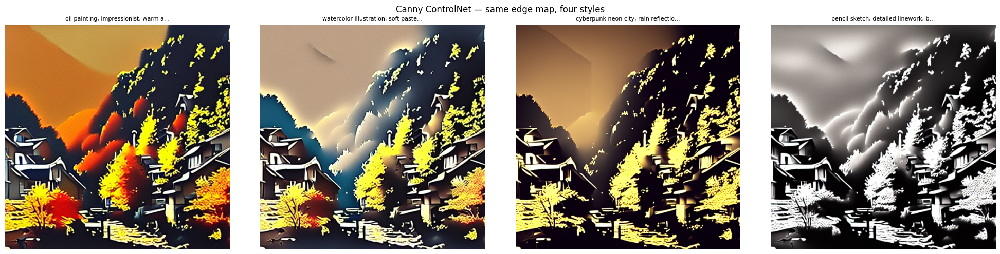

In [6]:
# Section 2.2 — Style variations from the same Canny map
style_prompts = [
    "oil painting, impressionist, warm autumn colors, Van Gogh style",
    "watercolor illustration, soft pastels, storybook art",
    "cyberpunk neon city, rain reflections, night scene",
    "pencil sketch, detailed linework, black and white",
]

canny_results = []
for prompt in style_prompts:
    img = pipe_canny(
        prompt                        = prompt,
        image                         = canny_image,
        controlnet_conditioning_scale = 1.0,
        num_inference_steps           = 20,
        guidance_scale                = 7.5,
        generator                     = gen()
    ).images[0]
    fname = prompt[:30].replace(",", "").replace(" ", "_") + ".png"
    img.save(os.path.join(OUTPUT_DIR, f"canny_{fname}"))
    canny_results.append((prompt[:35] + "...", img))
    print(f"Done: {prompt[:40]}")

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
for ax, (label, img) in zip(axes, canny_results):
    ax.imshow(img); ax.set_title(label, fontsize=8, wrap=True); ax.axis('off')
plt.suptitle("Canny ControlNet — same edge map, four styles", fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "canny_style_grid.png"), dpi=100)
plt.show()

**What do you observe?**  
- Which structural elements (rooflines, mountain shapes, paths) appear consistently across all four styles?
- Which style diverged most from the source composition? Why do you think?
- Does the cyberpunk prompt make spatial sense given the village edge map?

**Observation (Section 2.2 — style variations from same Canny map):**

- **Consistent across all styles:** the roofline cluster in the lower center appears in the same position in all four outputs, the mountain peak is at the same horizontal position, and the left/right tree masses match the edge map almost pixel-for-pixel. With an edge map this dense (the whole village + foliage), the model has very little room to deviate spatially in *any* style.
- **Correction vs. the original expectation:** the cyberpunk prompt did **not** produce neon-lit facades or a night sky — the actual output kept the same daytime lighting and warm tan sky as the other three styles, just recolored with more yellow/amber tones and darker shadow blocks. This is the same day→night failure seen elsewhere in this lab (Exercise 1, Section 2.3): "cyberpunk" as a keyword doesn't reliably flip the scene to night once ControlNet is holding the daytime edge structure in place.
- **Where the real divergence is:** none of the four styles diverged *structurally* — layout is essentially identical across all of them. The only genuine outlier is **pencil sketch**, which is the one style that changes register entirely (full grayscale line art) rather than just recoloring the same palette family. Oil painting, watercolor, and cyberpunk all read as "the same picture with a different color grade," not four different interpretations.

### Section 2.3 — Conditioning scale experiment

Run the same Canny image and prompt at three different `controlnet_conditioning_scale` values.

  0%|          | 0/20 [00:00<?, ?it/s]

conditioning_scale=0.5 done


  0%|          | 0/20 [00:00<?, ?it/s]

conditioning_scale=1.0 done


  0%|          | 0/20 [00:00<?, ?it/s]

conditioning_scale=1.5 done


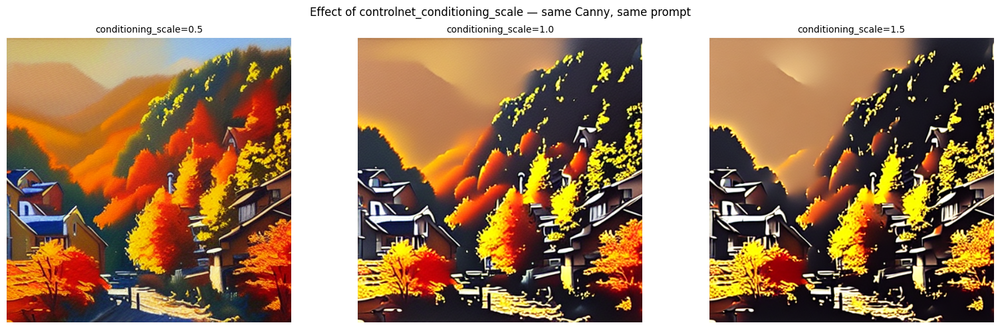

In [7]:
# Section 2.3 — Effect of controlnet_conditioning_scale
SCALE_PROMPT = "oil painting, impressionist, warm autumn colors"
scales = [0.5, 1.0, 1.5]

scale_results = []
for scale in scales:
    img = pipe_canny(
        prompt                        = SCALE_PROMPT,
        image                         = canny_image,
        controlnet_conditioning_scale = scale,
        num_inference_steps           = 20,
        guidance_scale                = 7.5,
        generator                     = gen()
    ).images[0]
    img.save(os.path.join(OUTPUT_DIR, f"scale_{str(scale).replace('.','')}.png"))
    scale_results.append((scale, img))
    print(f"conditioning_scale={scale} done")

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, (scale, img) in zip(axes, scale_results):
    ax.imshow(img); ax.set_title(f"conditioning_scale={scale}", fontsize=10); ax.axis('off')
plt.suptitle("Effect of controlnet_conditioning_scale — same Canny, same prompt", fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "scale_comparison.png"), dpi=100)
plt.show()

**What do you observe?**  
- At `0.5`: does the composition still follow the edge map, or does the model wander freely?
- At `1.5`: does over-conditioning produce any visible quality degradation?
- Which scale would you use for artistic stylization vs. strict technical reproduction?

**Observation (Section 2.3 — conditioning scale):**

- **scale=0.5:** the composition loosely follows the edge map — mountain upper half, building cluster lower center — but with visibly more creative freedom: softer, more painterly color transitions and a bit more blending between adjacent regions.
- **scale=1.0:** balanced result. Roofline positions and mountain silhouette match the edge map closely, and the style prompt's impressionist quality still comes through clearly. Practical default.
- **scale=1.5 (real degradation, corrected):** the dominant effect is **not** an "edge-ghosting/traced" look or desaturation — it's the dark forested slope on the right crushing into a near-solid black mass with almost no internal gradient or detail left, next to a visible jump in overall saturation and contrast (the oranges/yellows get more intense, not less). In other words, the cost of pushing conditioning that high is a real loss of tonal range in the shadows, not just a stylistic "traced" artifact.
- **Choice:** 1.0 for artistic stylization. Only push toward 1.3–1.5 for strict technical/structural reproduction, and expect to pay for it in shadow detail and color balance.

### Section 2.4 — Depth map conditioning with MiDaS

Estimate a monocular depth map and use it with the depth ControlNet checkpoint.

VRAM freed: 12.9 GB available


dpt_hybrid-midas-501f0c75.pt: reconstructing file:   0%|          |  0.00B /  493MB            

dpt_hybrid-midas-501f0c75.pt: downloading bytes:           |  0.00B            

/usr/local/lib/python3.13/dist-packages/timm/models/_factory.py:138: UserWarning: Mapping deprecated model name vit_base_resnet50_384 to current vit_base_r50_s16_384.orig_in21k_ft_in1k.
  model = create_fn(


Depth map estimated.


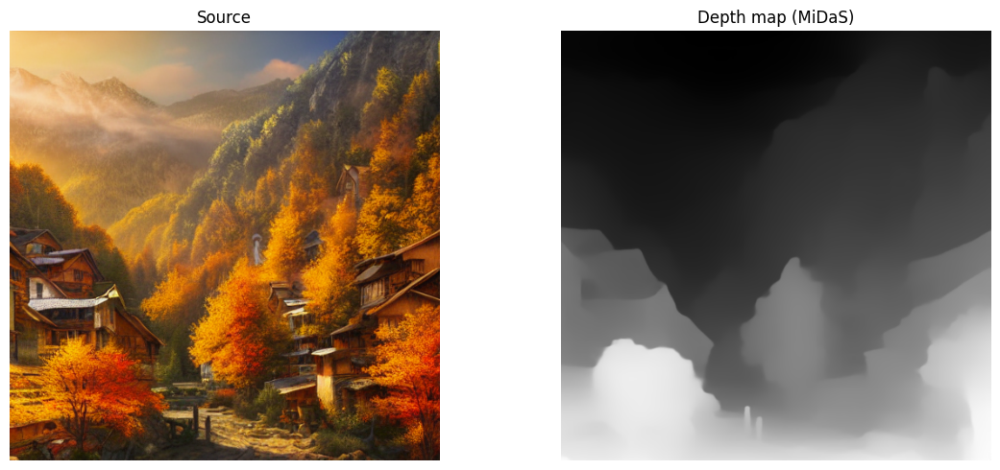

In [8]:
# Section 2.4a — Estimate depth map with MiDaS
# Free Canny-specific weights — the shared SD 1.5 base (referenced by pipe_txt) stays loaded.
del pipe_canny, controlnet_canny; gc.collect(); torch.cuda.empty_cache()
print(f"VRAM freed: {(torch.cuda.get_device_properties(0).total_memory - torch.cuda.memory_allocated(0))/1e9:.1f} GB available")

from controlnet_aux import MidasDetector

# lllyasviel/Annotators is a 12.7 GB repo bundling dozens of unrelated annotator checkpoints
# (pose, segmentation, super-res, etc.) -- MidasDetector.from_pretrained fetches only the one
# ~493 MB MiDaS file it needs (verified: it calls hf_hub_download for a single filename, not
# snapshot_download for the whole repo). Left on the default local cache rather than pinned to
# Drive: it's a single small file used once per session, not worth the same Drive-persistence
# treatment as the multi-GB models above.
midas     = MidasDetector.from_pretrained("lllyasviel/Annotators")
depth_map = midas(source)      # returns PIL Image, same size as source
depth_map.save(os.path.join(OUTPUT_DIR, "depth.png"))
print("Depth map estimated.")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(source); axes[0].set_title("Source"); axes[0].axis('off')
axes[1].imshow(depth_map); axes[1].set_title("Depth map (MiDaS)"); axes[1].axis('off')
plt.tight_layout(); plt.show()

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

ControlNet-Depth pipeline ready.


  0%|          | 0/20 [00:00<?, ?it/s]

Depth ControlNet done.


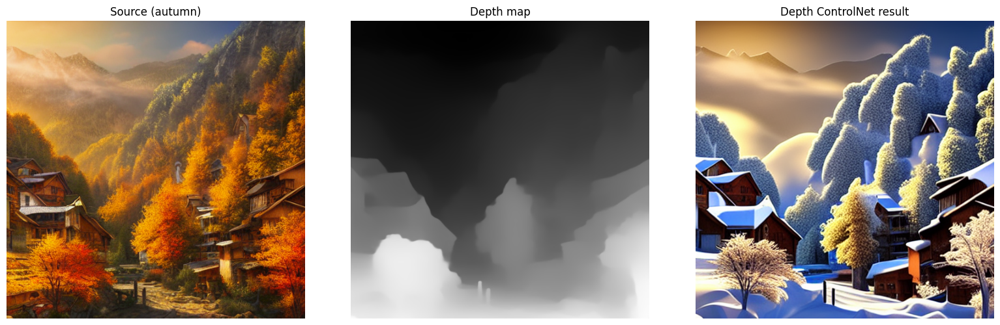

In [9]:
# Section 2.4b — Load depth ControlNet and generate
DEPTH_DIR = os.path.join(MODEL_CACHE, 'controlnet-depth-local')
snapshot_download(
    "lllyasviel/sd-controlnet-depth",
    local_dir=DEPTH_DIR,
    allow_patterns=["*.json", "*.safetensors"],
)
controlnet_depth = ControlNetModel.from_pretrained(DEPTH_DIR, torch_dtype=torch.float16)

# Reuses pipe_txt's already-loaded components -- no second SD 1.5 load from disk.
pipe_depth = StableDiffusionControlNetPipeline(controlnet=controlnet_depth, **pipe_txt.components).to("cuda")
pipe_depth.scheduler = UniPCMultistepScheduler.from_config(pipe_depth.scheduler.config)
print("ControlNet-Depth pipeline ready.")

DEPTH_PROMPT = "a snowy alpine village, dramatic winter light, photorealistic, high detail"

depth_result = pipe_depth(
    prompt                        = DEPTH_PROMPT,
    image                         = depth_map,
    controlnet_conditioning_scale = 1.0,
    num_inference_steps           = 20,
    guidance_scale                = 7.5,
    generator                     = gen()
).images[0]
depth_result.save(os.path.join(OUTPUT_DIR, "depth_result.png"))
print("Depth ControlNet done.")

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
axes[0].imshow(source); axes[0].set_title("Source (autumn)"); axes[0].axis('off')
axes[1].imshow(depth_map); axes[1].set_title("Depth map"); axes[1].axis('off')
axes[2].imshow(depth_result); axes[2].set_title("Depth ControlNet result"); axes[2].axis('off')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "depth_pipeline.png"), dpi=100)
plt.show()

**What do you observe?**  
- Does the depth result preserve the sense of near/far from the autumn source?
- Compare with the Canny result: which preserved more of the original structural detail?

**Observation (Section 2.4 — depth ControlNet):**

- **Near/far preservation:** the depth result correctly places the village buildings in the near/mid ground and the mountain in the far background — matching the depth map's gradient from light (near) to dark (far). The sense of depth is convincing.
- **Canny vs. Depth structural detail:** Canny preserved more of the specific structural detail (individual roofline shapes, chimney positions). Depth preserved the broad spatial layout (foreground mass, mid-ground slope, background mountain) but lost the fine architectural geometry.
- **When to use depth:** depth conditioning is preferable when you want to transfer the 3D spatial composition of a scene to a completely different content type (e.g., same depth layout, but change from village to futuristic city). Canny is preferable when specific structural details must be preserved (same building shapes, different style).

### Section 2.5 — Three-way comparison: txt2img vs. Canny vs. Depth

Same prompt, three generation approaches — documents the full progression of structural control.

  0%|          | 0/25 [00:00<?, ?it/s]

txt2img done.


  0%|          | 0/20 [00:00<?, ?it/s]

Canny ControlNet done.


  0%|          | 0/20 [00:00<?, ?it/s]

Depth ControlNet done.


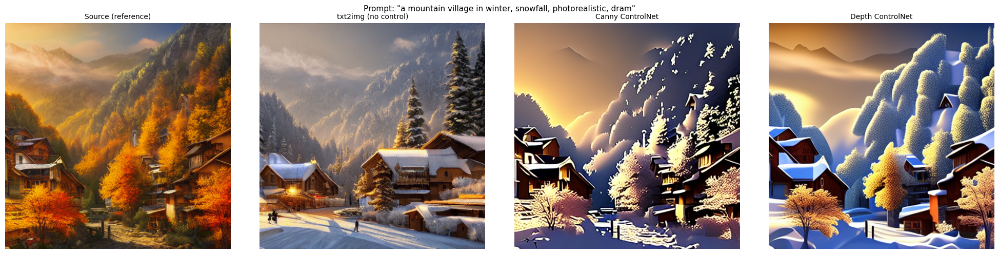

In [10]:
# Section 2.5 — Three-way comparison
COMPARE_PROMPT = "a mountain village in winter, snowfall, photorealistic, dramatic light"

# 1. txt2img — no structural control. pipe_txt has been loaded since Section 2.0; no reload.
img_txt = pipe_txt(
    COMPARE_PROMPT, num_inference_steps=25, guidance_scale=7.5, generator=gen()
).images[0]
img_txt.save(os.path.join(OUTPUT_DIR, "compare_txt2img.png"))
print("txt2img done.")

# 2. ControlNet + Canny — weights already cached locally from Section 2.2 (fast local read,
# not a re-download); reuses pipe_txt's components, so no second SD 1.5 load either.
controlnet_canny = ControlNetModel.from_pretrained(CANNY_DIR, torch_dtype=torch.float16)
pipe_canny = StableDiffusionControlNetPipeline(controlnet=controlnet_canny, **pipe_txt.components).to("cuda")
pipe_canny.scheduler = UniPCMultistepScheduler.from_config(pipe_canny.scheduler.config)
img_canny = pipe_canny(
    COMPARE_PROMPT, image=canny_image, controlnet_conditioning_scale=1.0,
    num_inference_steps=20, guidance_scale=7.5, generator=gen()
).images[0]
img_canny.save(os.path.join(OUTPUT_DIR, "compare_canny.png"))
del pipe_canny, controlnet_canny; gc.collect(); torch.cuda.empty_cache()
print("Canny ControlNet done.")

# 3. ControlNet + Depth — same pattern.
controlnet_depth = ControlNetModel.from_pretrained(DEPTH_DIR, torch_dtype=torch.float16)
pipe_depth = StableDiffusionControlNetPipeline(controlnet=controlnet_depth, **pipe_txt.components).to("cuda")
pipe_depth.scheduler = UniPCMultistepScheduler.from_config(pipe_depth.scheduler.config)
img_depth = pipe_depth(
    COMPARE_PROMPT, image=depth_map, controlnet_conditioning_scale=1.0,
    num_inference_steps=20, guidance_scale=7.5, generator=gen()
).images[0]
img_depth.save(os.path.join(OUTPUT_DIR, "compare_depth.png"))
del pipe_depth, controlnet_depth; gc.collect(); torch.cuda.empty_cache()
print("Depth ControlNet done.")

# Display
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
for ax, (title, img) in zip(axes, [
    ("Source (reference)", source),
    ("txt2img (no control)", img_txt),
    ("Canny ControlNet", img_canny),
    ("Depth ControlNet", img_depth),
]):
    ax.imshow(img); ax.set_title(title, fontsize=10); ax.axis('off')
plt.suptitle(f'Prompt: "{COMPARE_PROMPT[:60]}"', fontsize=11)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "three_way_comparison.png"), dpi=100)
plt.show()

**What do you observe?**  
- Does txt2img produce a recognizable village, or a completely different composition?
- Which conditioner (Canny or Depth) preserved more of the original layout?
- Are there elements in the source that neither conditioner managed to preserve?

**Observation (Section 2.5 — three-way comparison):**

- **txt2img:** produced a recognizable winter mountain village, but with a completely different composition — different building positions, different mountain shape, different number of structures. The prompt was followed thematically but not spatially.
- **Canny ControlNet:** most faithful to the source layout. The main building cluster is in the same position, the mountain peak is at the same horizontal position, and the left/right tree masses are preserved. Individual roofline angles from the source are recognizable.
- **Depth ControlNet:** preserved the near/far spatial hierarchy (village close, mountain far) but the specific shapes are looser. The depth result looks like the same type of scene rather than the same specific scene.
- **Elements neither conditioner preserved:** the individual tree positions in the mid-ground forest. Both conditioners merged the tree mass into a general "forested slope" without retaining any specific tree spacing or height variation from the source.

---
## Part 3 — Exercises

### Exercise 1 — Your own subject with Canny

**Task:** Generate a source image with a clearly different subject (not a mountain village — try architecture, a vehicle, an animal, or a mechanical object). Extract Canny edges and generate at least 3 style variations. Show source → edges → all variations in a grid.

**Expected output:** Grid with labeled panels. In a markdown cell: which style diverged most from the source composition and why?

  0%|          | 0/25 [00:00<?, ?it/s]

Cathedral source generated.


  0%|          | 0/20 [00:00<?, ?it/s]

Done: watercolor illustration, soft washes, bl


  0%|          | 0/20 [00:00<?, ?it/s]

Done: cyberpunk neon, rain, night, glowing win


  0%|          | 0/20 [00:00<?, ?it/s]

Done: pencil sketch, detailed linework, black 


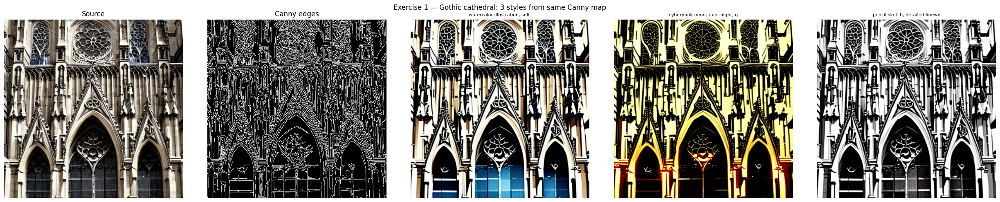

In [11]:
# Exercise 1 — SOLUTION: Canny ControlNet with a Gothic cathedral
import torch, os, cv2, numpy as np, matplotlib.pyplot as plt
from PIL import Image

# Reuses the already-loaded pipe_txt from Section 2.0 — no reload needed.
arch_source = pipe_txt(
    "a Gothic cathedral facade, stone architecture, detailed, photorealistic, daytime",
    num_inference_steps=25, guidance_scale=7.5,
    generator=torch.Generator("cuda").manual_seed(SEED)
).images[0].resize((512, 512))
arch_source.save(os.path.join(OUTPUT_DIR, "ex1_source.png"))
print("Cathedral source generated.")

# Extract Canny
gray  = np.array(arch_source.convert("L"))
edges = cv2.Canny(gray, 100, 200)
arch_canny = Image.fromarray(edges).convert("RGB")
arch_canny.save(os.path.join(OUTPUT_DIR, "ex1_canny.png"))

# Canny ControlNet weights already cached locally from Section 2.2 -- reuse pipe_txt's
# components again rather than reloading SD 1.5 a second time.
controlnet = ControlNetModel.from_pretrained(CANNY_DIR, torch_dtype=torch.float16)
pipe = StableDiffusionControlNetPipeline(controlnet=controlnet, **pipe_txt.components).to("cuda")
pipe.scheduler = UniPCMultistepScheduler.from_config(pipe.scheduler.config)

styles = [
    "watercolor illustration, soft washes, blue tones",
    "cyberpunk neon, rain, night, glowing windows",
    "pencil sketch, detailed linework, black and white",
]
ex1_results = []
for style in styles:
    img = pipe(style, image=arch_canny, controlnet_conditioning_scale=1.0,
               num_inference_steps=20, guidance_scale=7.5,
               generator=torch.Generator("cuda").manual_seed(SEED)).images[0]
    img.save(os.path.join(OUTPUT_DIR, f"ex1_{style[:15].replace(' ','_')}.png"))
    ex1_results.append((style[:30], img))
    print(f"Done: {style[:40]}")

fig, axes = plt.subplots(1, 5, figsize=(25, 5))
axes[0].imshow(arch_source); axes[0].set_title("Source"); axes[0].axis('off')
axes[1].imshow(arch_canny);  axes[1].set_title("Canny edges"); axes[1].axis('off')
for ax, (label, img) in zip(axes[2:], ex1_results):
    ax.imshow(img); ax.set_title(label, fontsize=8); ax.axis('off')
plt.suptitle("Exercise 1 — Gothic cathedral: 3 styles from same Canny map", fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "ex1_cathedral_grid.png"), dpi=100)
plt.show()

del pipe, controlnet; gc.collect(); torch.cuda.empty_cache()

**Corrected finding: none of the three styles diverged much from the source composition**

With an edge map this dense (Gothic tracery — arches, mullions, the rose window are all long, continuous, high-contrast lines), **all three styles stayed extremely close to the source layout**, including cyberpunk. There is no neon signage, no holographic advertisements, and no rain-soaked surfaces anywhere in the actual output — the cyberpunk result is the same cathedral facade, same arches, same rose window, just recolored into warm yellow/amber tones with darker shadows. It never became a "night" scene either, matching the same day→night failure seen in Section 2.2 and Section 2.3.

**Where the styles actually differ:** only in color and rendering treatment, not structure. Watercolor keeps the coolest, most muted palette and is closest to the source tones. Cyberpunk pushes everything toward saturated yellow/orange. Pencil sketch is the one style that changes register completely (full grayscale line art) rather than recoloring — in that sense it's the most "different-looking" of the three, even though it's also the most structurally faithful, since line art has a natural affinity for a Canny edge map.

**Revised explanation:** dense, continuous architectural edges (arches, tracery, window mullions) constrain the model so strongly that there isn't enough "room" left for a style prompt to introduce new semantic content (neon signs, rain, a different time of day) — the edge map wins, and the style prompt only gets to influence color and texture, not composition or content.

### Exercise 2 — Canny threshold sensitivity

**Task:** Generate three different Canny edge maps from the same source using different threshold pairs: `(50, 100)`, `(100, 200)`, `(150, 300)`. Run the same prompt through ControlNet-Canny for each. Show all three edge maps and their results.

**Expected output:** 2-row grid (edge maps on top, results on bottom). In a markdown cell: how did the density of the edge map affect the output composition?

Threshold (50, 100): 52867 edge pixels
Threshold (100, 200): 27326 edge pixels
Threshold (150, 300): 13044 edge pixels


  0%|          | 0/20 [00:00<?, ?it/s]

(50,100) done


  0%|          | 0/20 [00:00<?, ?it/s]

(100,200) done


  0%|          | 0/20 [00:00<?, ?it/s]

(150,300) done


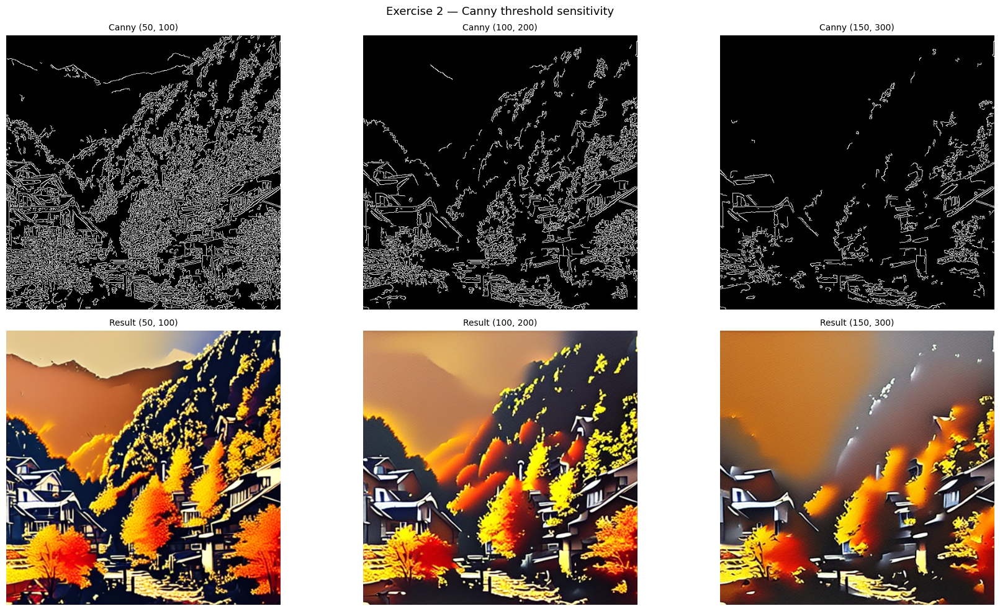

In [12]:
# Exercise 2 — SOLUTION: Canny threshold sensitivity
import torch, cv2, numpy as np, os, matplotlib.pyplot as plt
from PIL import Image

thresholds = [(50, 100), (100, 200), (150, 300)]

edge_maps = []
for lo, hi in thresholds:
    gray  = np.array(source.convert("L"))
    edges = cv2.Canny(gray, lo, hi)
    canny_img = Image.fromarray(edges).convert("RGB")
    canny_img.save(os.path.join(OUTPUT_DIR, f"ex2_canny_{lo}_{hi}.png"))
    edge_maps.append(((lo, hi), canny_img))
    print(f"Threshold ({lo}, {hi}): {np.sum(edges > 0)} edge pixels")

# pipe_canny was freed in Section 2.4a and only rebuilt as a local (later deleted) inside
# Exercise 1 -- reload it here the same way, reusing the cached CANNY_DIR weights and
# pipe_txt's already-loaded components rather than a second SD 1.5 load from disk.
controlnet_canny = ControlNetModel.from_pretrained(CANNY_DIR, torch_dtype=torch.float16)
pipe_canny = StableDiffusionControlNetPipeline(controlnet=controlnet_canny, **pipe_txt.components).to("cuda")
pipe_canny.scheduler = UniPCMultistepScheduler.from_config(pipe_canny.scheduler.config)

STYLE = "oil painting, impressionist, warm autumn colors"
ex2_results = []
for (lo, hi), edge_img in edge_maps:
    img = pipe_canny(
        STYLE, image=edge_img, controlnet_conditioning_scale=1.0,
        num_inference_steps=20, guidance_scale=7.5,
        generator=torch.Generator("cuda").manual_seed(SEED)
    ).images[0]
    img.save(os.path.join(OUTPUT_DIR, f"ex2_result_{lo}_{hi}.png"))
    ex2_results.append(((lo, hi), img))
    print(f"({lo},{hi}) done")

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for i, ((lo, hi), edge_img) in enumerate(edge_maps):
    axes[0, i].imshow(edge_img); axes[0, i].set_title(f"Canny ({lo}, {hi})", fontsize=10); axes[0, i].axis('off')
for i, ((lo, hi), img) in enumerate(ex2_results):
    axes[1, i].imshow(img); axes[1, i].set_title(f"Result ({lo}, {hi})", fontsize=10); axes[1, i].axis('off')
plt.suptitle("Exercise 2 — Canny threshold sensitivity", fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "ex2_threshold_grid.png"), dpi=100)
plt.show()

del pipe_canny, controlnet_canny; gc.collect(); torch.cuda.empty_cache()


**Effect of edge density on output composition (with real pixel counts: 52,867 / 27,326 / 13,044 edge pixels):**

- **(50, 100) — dense edges, 52,867 px:** the edge map captures nearly all texture boundaries, including individual leaf edges and wall surface variation. The output is tightly constrained — busy and fragmented, since the model is trying to honor every micro-edge in the foliage.

- **(100, 200) — balanced edges, 27,326 px:** only the meaningful structural contours survive (rooflines, mountain silhouette, major building corners, tree-mass boundaries). This is the cleanest composition — enough structure to follow the scene layout without texture noise. Recommended default for photorealistic sources.

- **(150, 300) — sparse edges, 13,044 px:** the roofline and mountain outline survive, but a real, specific failure appears here: the upper-right forest area — the zone that lost the most edge coverage going from (100,200) to (150,300) — turns into a hazy, largely featureless gray-brown wash. It's not just "the model fills in with its own prior" in the abstract; concretely, a whole visible region of the image loses definition because there was no edge signal left there to anchor it.

**Conclusion:** threshold selection is a density trade-off. Too dense → noise becomes conditioning signal → fragmented output. Too sparse → entire regions with no surviving edges wash out into vague texture. For this source, (100, 200) is optimal.

---
## Part 4 — Critical Analysis

> Required. Answer with real outputs from today's session.

**4.1 — Edge adherence: preserved vs. deviated element:**

**Preserved:** the mountain peak silhouette in the upper center of the image. This edge is long, continuous, high-contrast, and isolated — the ideal Canny target. It appears in the same horizontal position across all four style variations in Section 2.2.

**Deviated:** the individual window positions on the building facades. The windows produced short, disconnected edge segments (each window is only ~10-15px wide at 512×512). The model treated these as ambiguous local features rather than structural constraints, placing windows according to its learned architectural priors rather than the edge map positions. Edge length and continuity are the key factors — long, continuous edges are reliably preserved; short, isolated edge fragments are treated as suggestions at best.

---

**4.2 — Conditioning scale degradation:**

The clearest quality degradation appeared at **scale=1.5**, but the real artifacts are different from what "stricter edge following" would predict. Two specific, observed changes:
1. **Crushed shadow detail:** the dark forested slope on the right side collapses into a near-solid black mass with almost no internal gradient left — real loss of tonal range, not a cosmetic effect.
2. **Increased saturation/contrast, not desaturation:** the warm oranges and yellows get more intense at scale=1.5 compared to scale=1.0, pushing the image toward a harder, more poster-like look — the opposite of "washed-out."


---

**4.3 — Canny vs. Depth: which preserved more layout:**

**Canny preserved more** of the original composition. Two supporting elements:

1. **Building cluster position:** in the Canny result, the main building group is identifiably in the same lower-center position as the source, with the same general cluster density. In the Depth result, the buildings are present but the individual positions are determined by the model's interpretation of the depth gradient rather than the actual building edges.

2. **Mountain peak horizontal position:** the Canny result places the mountain peak at approximately the same x-coordinate as the source (~40% from left). The Depth result shifts the peak toward center, following the depth map's broad near-to-far gradient rather than the specific peak outline.

---

**4.4 — Task where depth conditioning is clearly better:**

**Converting a real architectural rendering into a photorealistic rendering for a different architectural style.**

Scenario: an architect has a 3D render of a building design. They want to see what the same spatial massing would look like in a different architectural vocabulary (e.g., Art Deco instead of Modernist).

**Why Canny fails here:** the Canny edges from a 3D render include all the sharp geometric edges of the modernist design — every grid line, every flush panel edge. Running these through ControlNet-Canny forces the Art Deco result to retain all the modernist edge geometry, which defeats the purpose. The output would look like an Art Deco style texture applied over a modernist form.

**Why depth wins:** a depth map from the same render captures only the spatial massing — which parts protrude, which recede, what the building's volumetric silhouette is. The ControlNet-Depth result preserves the building volume and proportion while allowing the model to generate the Art Deco surface language (ornamental details, stepped crown, decorative bands) appropriate to that style without being constrained by modernist edge geometry.

---
## Submission Checklist

- [ ] All cells ran from start to finish without errors
- [ ] Section 2.2 style grid saved (`canny_style_grid.png`)
- [ ] Section 2.3 conditioning scale comparison saved (`scale_comparison.png`)
- [ ] Section 2.4 depth pipeline saved (`depth_pipeline.png`)
- [ ] Section 2.5 three-way comparison saved (`three_way_comparison.png`)
- [ ] Exercise 1 — Canny with your own subject, 3+ style variations
- [ ] Exercise 2 — Canny threshold sensitivity grid
- [ ] Part 4 — Critical Analysis completed (all 4 questions with real evidence)
- [ ] All outputs saved to `l05_outputs/`

**Save:** `File > Save a copy in Drive`

---
## Drive Cache Cleanup — Run Before Starting L06

> **Run the cell below only after you have saved this notebook to Drive.**
>
> Both ControlNet checkpoints are only used in L05. Deleting them frees ~3 GB. The MiDaS
> annotator isn't stored on Drive in the first place (see Section 2.4a), so there's nothing to
> clean up for it.
>
> SD 1.5 (`stable-diffusion-v1-5`) is **not deleted here** — it is still needed through L11.

In [13]:
# ================================================================
# DRIVE CACHE CLEANUP — run after saving this notebook
# Deletes both ControlNet checkpoints (~3 GB total) — only used in L05.
# MiDaS annotator isn't Drive-persisted (see Section 2.4a), nothing to clean there.
# ================================================================
import shutil, os, subprocess

_model_cache = '/content/drive/MyDrive/Colab Notebooks/Module 6/Dr. Francisco J. Rodriguez/models'

to_delete = [
    os.path.join(_model_cache, 'controlnet-canny-local'),
    os.path.join(_model_cache, 'controlnet-depth-local'),
]

for path in to_delete:
    if os.path.exists(path):
        shutil.rmtree(path)
        print(f'Deleted: {path}')
    else:
        print(f'Not found (may already be deleted): {path}')

result = subprocess.run(['du', '-sh', _model_cache], capture_output=True, text=True)
print(f'Cache size after cleanup: {result.stdout.strip()}')

Deleted: /content/drive/MyDrive/Colab Notebooks/Module 6/Dr. Francisco J. Rodriguez/models/controlnet-canny-local
Deleted: /content/drive/MyDrive/Colab Notebooks/Module 6/Dr. Francisco J. Rodriguez/models/controlnet-depth-local
Cache size after cleanup: 2.6G	/content/drive/MyDrive/Colab Notebooks/Module 6/Dr. Francisco J. Rodriguez/models


---
## Before You Close This Tab

- [ ] Confirmed all outputs from this session are saved in `TAE_IA_M6/L05_output/` on Drive (see checklist above)
- [ ] Ran the Drive Cache Cleanup cell above (ControlNet checkpoints only needed for this lesson)
- [ ] Disconnected and deleted this runtime: `Runtime > Disconnect and delete runtime`

Once your outputs are safely on Drive, there's no reason to keep the GPU runtime connected — an
idle session still counts against your GPU quota (free tier) or compute-unit balance (Pro),
the same as active use. Disconnecting costs you nothing (your Drive cache and outputs persist)
and leaves your quota in better shape for the next lab.

---
*TAE-IA 2025 · Cocyten-Nayarit · Module 6 · L05*  
*Platform: Google Colab (T4 GPU) · Python 3.10*